# Section 3.7 — Inventory of statistical tests

This notebook contains the code examples from [Section 3.7 Inventory of statistical tests]() from the **No Bullshit Guide to Statistics**.

#### Notebook setup

In [1]:
# Ensure required Python modules are installed
%pip install --quiet numpy scipy seaborn pandas ministats

Note: you may need to restart the kernel to use updated packages.


In [2]:
# load Python modules
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Plot helper functions
from ministats import plot_pdf

In [4]:
# Figures setup
plt.clf()  # needed otherwise `sns.set_theme` doesn't work
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    rc={"font.family": "serif",
        "font.serif": ["Palatino", "DejaVu Serif", "serif"],
        "figure.figsize": (10, 3)},
)
%config InlineBackend.figure_format = 'retina'

<Figure size 640x480 with 0 Axes>

In [5]:
# Simple float __repr__  
if int(np.__version__.split(".")[0]) >= 2:
    np.set_printoptions(legacy='1.25')
        
# set random seed for repeatability
np.random.seed(42)

In [6]:
# Download datasets/ directory if necessary
from ministats import ensure_datasets
ensure_datasets()

datasets/ directory already exists.


## Definitions

## Assumptions

### Normality assumption

Here is a useful function for generating synthetic data to use with the parametric tests below.

In [7]:

import numpy as np
from scipy.stats import norm

def gen_normal_samples(mus=[0], sigmas=[1], ns=[30], seed=None):
    """
    Generate random samples of sizes `ns` from the normal data model
    with parameters taken from `mus` and `sigmas`.
    """
    if seed is not None:
        np.random.seed(seed)

    samples = []
    for mu, sigma, n in zip(mus, sigmas, ns):
        rvN = norm(mu, sigma)
        sample = rvN.rvs(n)
        samples.append(sample)

    return samples




## NHST procedure

## Categorization of statistical test recipes

## Z-Tests

### One-sample $z$-test

See the [examples/one_sample_z-test.ipynb](../examples/one_sample_z-test.ipynb) notebook.

## Proportion tests

### One-sample $z$-test for a proportion

In [8]:

k = 3
n = 5

p0 = 0.3

phat = k / n 
se = np.sqrt( p0 * (1-p0) / n)


z = (phat - p0) / se
print("z =", z)

from scipy.stats import norm

rvZ0 = norm(0,1)
pvalue = rvZ0.cdf(-abs(z)) + (1 - rvZ0.cdf(abs(z)))
pvalue

z = 1.4638501094227998


0.14323490752466972

In [9]:
from statsmodels.stats.proportion import proportions_ztest

proportions_ztest(k, n, value=p0, prop_var=p0)

(1.4638501094227996, 0.1432349075246697)

#### Confidence interval

In [10]:
alpha = 0.1
sehat = np.sqrt( phat * (1-phat) / n)

[phat + rvZ0.ppf(alpha/2)*sehat, phat + rvZ0.ppf(1-alpha/2)*sehat ]

[0.23963062588979633, 0.9603693741102035]

In [11]:
from statsmodels.stats.proportion import proportion_confint

proportion_confint(k, n, alpha=0.1)

(0.23963062588979633, 0.9603693741102036)

### Binomial test

cf. https://en.wikipedia.org/wiki/Binomial_test

In [12]:
# Exact probability model for the sum of `n` Bernoulli events
from scipy.stats import binom
rvP0 = binom(n=5, p=p0)

# Probability of the observed outcome k
kprob = rvP0.pmf(k)   

allks = np.arange(0,5+1) # array of all possible outcomes
probs = rvP0.pmf(allks)  # probabilities of all outcomes

# Compute the sum of the prob of all outcomes
# that have less probability than observed outcome.
pvalue = np.sum(probs[probs<=kprob])
pvalue

0.16307999999999992

In [13]:
from scipy.stats import binomtest
binres = binomtest(k, n, p=p0)
binres.pvalue

0.16308

In [14]:
from statsmodels.stats.proportion import binom_test
binom_test(k, n, prop=p0)

0.16308

### Two-sample $z$-test for proportions

## T-tests
### One sample $t$-test

See the [examples/one_sample_t-test.ipynb](../examples/one_sample_t-test.ipynb) notebook.

### Welch's two-sample $t$-test

### Student's two-sample $t$-test

(explain pooled variance as special case "Two sample t-test", but inferior)

### Paired $t$-test

## Chi-square tests

### Chi-square test for goodness of fit

#### Example: are the digits of $\pi$ random?

In [15]:
pidigits = [99959,  99757, 100026, 100230, 100230, 100359,  99548,  99800, 99985, 100106]
# obtained using   np.bincount(list(str(sympy.N(sympy.pi, 1_000_000)).replace('.','')))

os = pidigits           # observed
es = [1_000_000/10]*10  # expected (uniform)

from scipy.stats import chisquare
res = chisquare(f_obs=os, f_exp=es)
res.statistic, res.pvalue

(5.51852, 0.7869706202650394)

See original blog post for useful historical context about this
https://probabilityandstats.wordpress.com/2017/03/14/are-digits-of-pi-random/

#### Example: birds foraging

Bird foraging behavior was investigated in an old-growth forest of Oregon. In the forest, 44% of the canopy volume was Douglas fir, 24% was ponderosa pine, 29% was grand fir, and 3% was western larch. The authors observed the behavior of several species of birds, one of which was the red-breasted nuthatch. They made 189 observations of this species foraging, recording 43 of observations in Douglas fir, 52 in ponderosa pine, 54 in grand fir, and 40 in western larch.


Using a chi-square test, we can test the null hypothesis that the proportions of foraging events are equal to the proportions of canopy volume. Considered a $p$-value less than 1% to be significant.

cf. https://docs.scipy.org/doc/scipy/tutorial/stats/hypothesis_chisquare.html


In [16]:
import numpy as np

# Observed counts
os = np.array([43, 52, 54, 40])
n = np.sum(os)

# Expected counts based on canopy volume proportions
es = n * np.array([0.44, 0.24, 0.29, 0.03])

# Run the chi-square test for goodness of fit
from scipy.stats import chisquare
res = chisquare(f_obs=os, f_exp=es)
res.statistic, res.pvalue

(228.23515947653874, 3.3295585338846486e-49)

### Chi-square test of independence

#### Example 1: starting from counts

In [17]:
# rows: category of X
# columns: category of Y
observed = np.array([
    [30, 20, 10],
    [20, 30, 40],
])

from scipy.stats import chi2_contingency
res = chi2_contingency(observed, correction=False)
res.statistic, res.dof, res.pvalue

(16.666666666666668, 2, 0.00024036947641951404)

In [18]:
# Compute by manually calculating expected frequencies under H0
n = observed.sum()
y_marginal = observed.sum(axis=0) / n
x_marginal = observed.sum(axis=1) / n
expected = n * x_marginal[:,np.newaxis] * y_marginal

# And degrees of freedom
dof = observed.size - sum(observed.shape) + 1   # = I*K - K - I + 1

from scipy.stats import chisquare
res = chisquare(f_obs=observed, f_exp=expected,
                axis=None, ddof=observed.size - 1 - dof)
res.statistic, res.pvalue

(16.666666666666668, 0.00024036947641951404)

#### Example 2: starting from categorical observations

In [19]:
x = ["A", "A", "A", "A", "A", "A", "A", "A", "A", "A", "A", "A",
     "B", "B", "B", "B", "B", "B", "B", "B", "B", "B", "B", "B",]
y = ["yes", "yes", "yes", "yes", "yes", "yes", "yes", "yes", "no",  "no",  "no",  "no",
     "yes", "yes", "yes", "yes", "no",  "no",  "no",  "no",  "no",  "no",  "no",  "no",]

import pandas as pd
observed2 = pd.crosstab(x, y)
print(observed2)

from scipy.stats import chi2_contingency
res2 = chi2_contingency(observed2, correction=False)
res2.statistic, res2.dof, res2.pvalue

col_0  no  yes
row_0         
A       4    8
B       8    4


(2.6666666666666665, 1, 0.10247043485974996)

In [20]:
import statsmodels.api as sm
table = sm.stats.Table(observed2, shift_zeros=False)
res2alt = table.test_nominal_association()
res2alt.statistic, res2alt.df, res2alt.pvalue

(2.6666666666666674, 1, 0.10247043485974905)

### Chi-square test for homogeneity



In [21]:
import numpy as np
from scipy.stats import chi2_contingency

# rows: populations
# columns: categories of the outcome
observed3 = np.array([
    [30, 50, 20],   # population 1
    [45, 40, 15],   # population 2
    [25, 45, 30],   # population 3
])

res3 = chi2_contingency(observed3, correction=False)
res3.statistic, res3.dof, res3.pvalue

(12.995726495726496, 4, 0.011296693934973229)

### Chi-square test for the population variance

## Analysis of variance (ANOVA) tests

### One-way analysis of variance (ANOVA)

#### Example: doctors workplace

In [22]:
doctors = pd.read_csv("datasets/doctors.csv")
hos_scores = doctors[doctors["work"]=="hos"]["score"]
cli_scores = doctors[doctors["work"]=="cli"]["score"]
eld_scores = doctors[doctors["work"]=="eld"]["score"]

# One-way ANOVA
from scipy.stats import f_oneway
res = f_oneway(hos_scores, cli_scores, eld_scores)
res.pvalue

0.5526627461285655

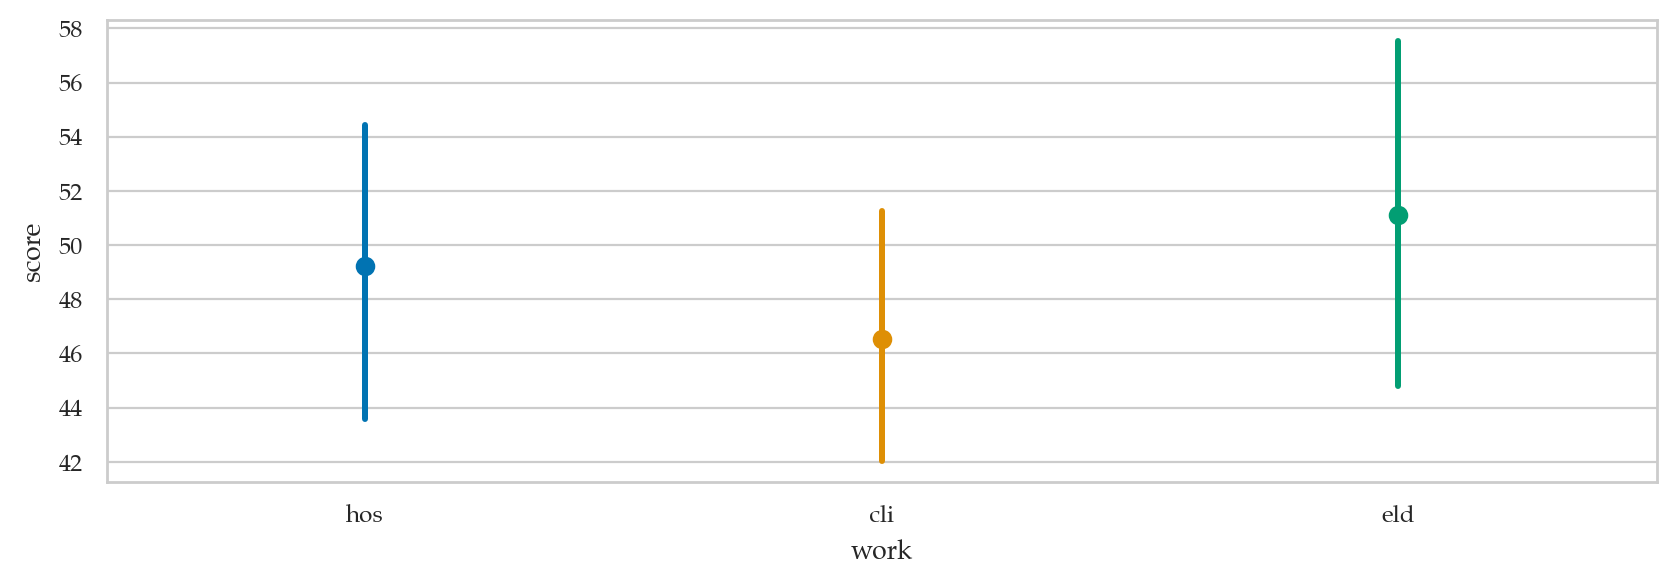

In [23]:
sns.pointplot(data=doctors, x="work", y="score", hue="work");

#### Example: synthetic dataset with one group differenrt

In [24]:
mus = [100, 100, 104]
sigmas = [5, 5, 5]
ns = [20, 20, 20]
samples = gen_normal_samples(mus=mus, sigmas=sigmas, ns=ns, seed=46)
[sample1, sample2, sample3] = samples

# One-way ANOVA
from scipy.stats import f_oneway
res = f_oneway(sample1, sample2, sample3)
res.pvalue

0.002268927763807039

Correctly rejects $H_0$.

#### Example: synthetic dataset with all groups roughly the same

In [25]:
mus = [99.5, 100, 100.5]
sigmas = [5, 5, 5]
ns = [20, 20, 20]
samples = gen_normal_samples(mus=mus, sigmas=sigmas, ns=ns, seed=47)
[sample1, sample2, sample3] = samples

# One-way ANOVA
from scipy.stats import f_oneway
res = f_oneway(sample1, sample2, sample3)
res.pvalue

0.22426174367680077

Correctly fails to reject $H_0$.

## Nonparametric tests
Use when assumptions for other tests not valid

### Sign test for the population median

via https://vitalflux.com/sign-test-hypothesis-python-examples/

In [26]:
from scipy.stats import binomtest

n_pos = 6
n_neg = 9
n_min = min(n_pos, n_neg)
n_tot = n_pos + n_neg

# Calculate p-value (two-tailed) using the binomial test
binomtest(k=n_min, n=n_tot, p=0.5, alternative='two-sided')

BinomTestResult(k=6, n=15, alternative='two-sided', statistic=0.4, pvalue=0.6072387695312499)

In [27]:
n_max = max(n_pos, n_neg)
binomtest(k=n_max, n=n_tot, p=0.5, alternative='two-sided')

BinomTestResult(k=9, n=15, alternative='two-sided', statistic=0.6, pvalue=0.6072387695312499)

### One-sample Wilcoxon signed-rank test

### Mann-Whitney U-test

example via https://www.reneshbedre.com/blog/mann-whitney-u-test.html

In [28]:
# dfw = pd.read_csv("https://reneshbedre.github.io/assets/posts/mann_whitney/genotype.csv")
# dfw.shape
# dfw

In [29]:
# from scipy.stats import mannwhitneyu
# mannwhitneyu(x=dfw["A"], y=dfw["B"], alternative="two-sided")

### Kruskal-Wallis analysis of variance by ranks

## Resampling methods

### Simulation tests

In [30]:
from ministats.hypothesis_tests import simulation_test

%psource simulation_test

def simulation_test(sample, rvH0, estfunc, alt="two-sided"):
    """
    Compute the p-value of the observed estimate `estfunc(sample)` under H0
    described by the random variable `rvH0`.
    """
    # 1. Compute the observed value of `estfunc`
    obsest = estfunc(sample)
    n = len(sample)

    # 2. Get sampling distribution of `estfunc` under H0
    sampl_dist_H0 = gen_sampling_dist(rvH0, estfunc, n)

    # 3. Compute the p-value
    tails = tailvalues(sampl_dist_H0, obsest, alt=alt)
    pvalue = len(tails) / len(sampl_dist_H0)
    return pvalue


### Two-sample permutation test

In [31]:
from ministats.hypothesis_tests import permutation_test

%psource permutation_test

def permutation_test(xsample, ysample, estfunc, P=10000):
    """
    Compute the p-value of the observed estimate `estfunc(xsample,ysample)`
    under the null hypothesis where the group membership is randomized.
    """
    # 1. Compute the observed value of `estfunc`
    obsest = estfunc(xsample, ysample)

    # 2. Get sampling dist. of `estfunc` under H0
    pestimates = []
    for i in range(0, P):
        rsx, rsy = resample_under_H0(xsample, ysample)
        pestimate = estfunc(rsx, rsy)
        pestimates.append(pestimate)

    # 3. Compute the p-value
    tails = tailvalues(pestimates, obsest)
    pvalue = len(tails) / len(pestimates)
    return pvalue


### Permutation ANOVA

In [32]:
from ministats.estimators import Fstat

%psource Fstat

def Fstat(*samples):
    I = len(samples)
    n = len(np.concatenate(samples))
    xbar = np.mean(np.concatenate(samples))
    SSbetween = sum(len(xi)*(np.mean(xi) - xbar)**2 for xi in samples)
    SSwithin = sum(np.sum((xi - np.mean(xi))**2) for xi in samples)
    MSbetween = SSbetween / (I - 1)
    MSwithin = SSwithin / (n - I)
    return MSbetween / MSwithin


In [33]:
from ministats import permutation_anova

%psource permutation_anova

def permutation_anova(samples, P=10000, alt="greater"):
    """
    Compute the p-value of the observed F-statistic for `samples` list
    under the null hypothesis where the group membership is randomized.
    """
    ns = [len(sample) for sample in samples]

    # 1. Compute the observed F-statistic
    obsfstat = Fstat(*samples)

    # 2. Get sampling dist. of F-statistic under H0
    pfstats = []
    for i in range(0, P):
        values = np.concatenate(samples)
        pvalues = np.random.permutation(values)
        psamples = []
        nstart = 0
        for nstep in ns:
            psample = pvalues[nstart:nstart+nstep]
            psamples.append(psample)
            nstart = nstart + nstep
        pfstat = Fstat(*psamples)
        pfstats.append(pfstat)

    # 3. Compute the p-value
    tails = tailvalues(pfstats, obsfstat, alt=alt)
    pvalue = len(tails) / len(pfstats)
    return pvalue


In [34]:
# test on three samples
from scipy.stats import norm

# Random samples
np.random.seed(43)
sample1 = norm(loc=0).rvs(size=30)
sample2 = norm(loc=0).rvs(size=30)
sample3 = norm(loc=0.7).rvs(size=30)

from ministats.estimators import Fstat
print("F =", Fstat(sample1, sample2, sample3))

np.random.seed(45)
permutation_anova([sample1, sample2, sample3])

F = 3.6808227678358847


0.0297

In [35]:
from ministats.estimators import Fstat

np.random.seed(45)
from scipy.stats import permutation_test
res = permutation_test([sample1,sample2,sample3], statistic=Fstat, alternative='greater')
res.statistic, res.pvalue

(3.6808227678358847, 0.0298)

In [36]:
# compare with analytical formula
from scipy.stats import f_oneway

res = f_oneway(sample1, sample2, sample3)
res.statistic, res.pvalue

(3.6808227678358865, 0.029206733498721386)

## Equivalence tests

See [examples/two_sample_equivalence_test.ipynb](../examples/two_sample_equivalence_test.ipynb) for an example.

## Distribution checks

### Kolmogorov-Smirnov test

### Shapiro-Wilk normality test

### Discussion

## Discussion

## Exercises

## Links